In [1]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM hospital_performance_final", engine)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

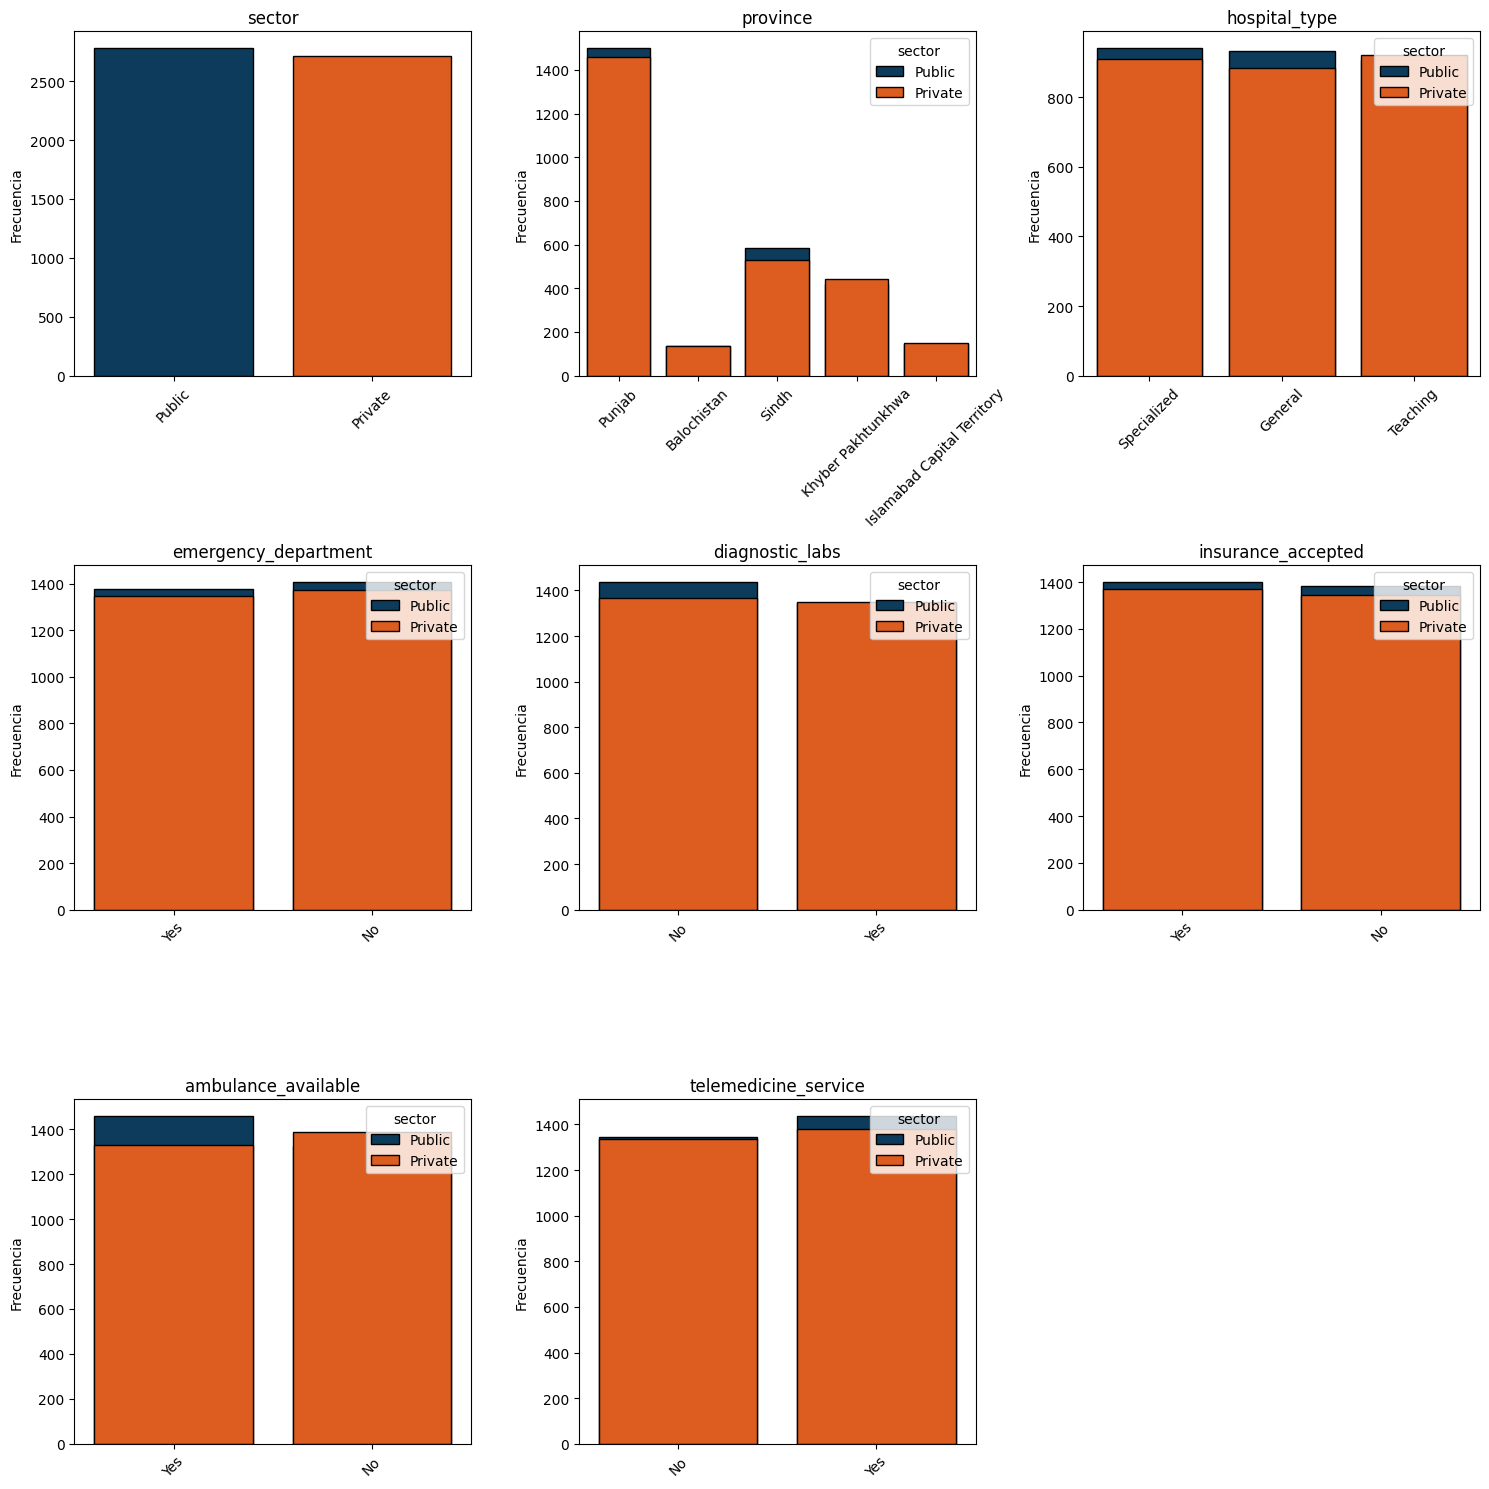

In [4]:
import math

# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 10  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=col,
        hue="sector",
        dodge=False,
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        ax=ax,
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

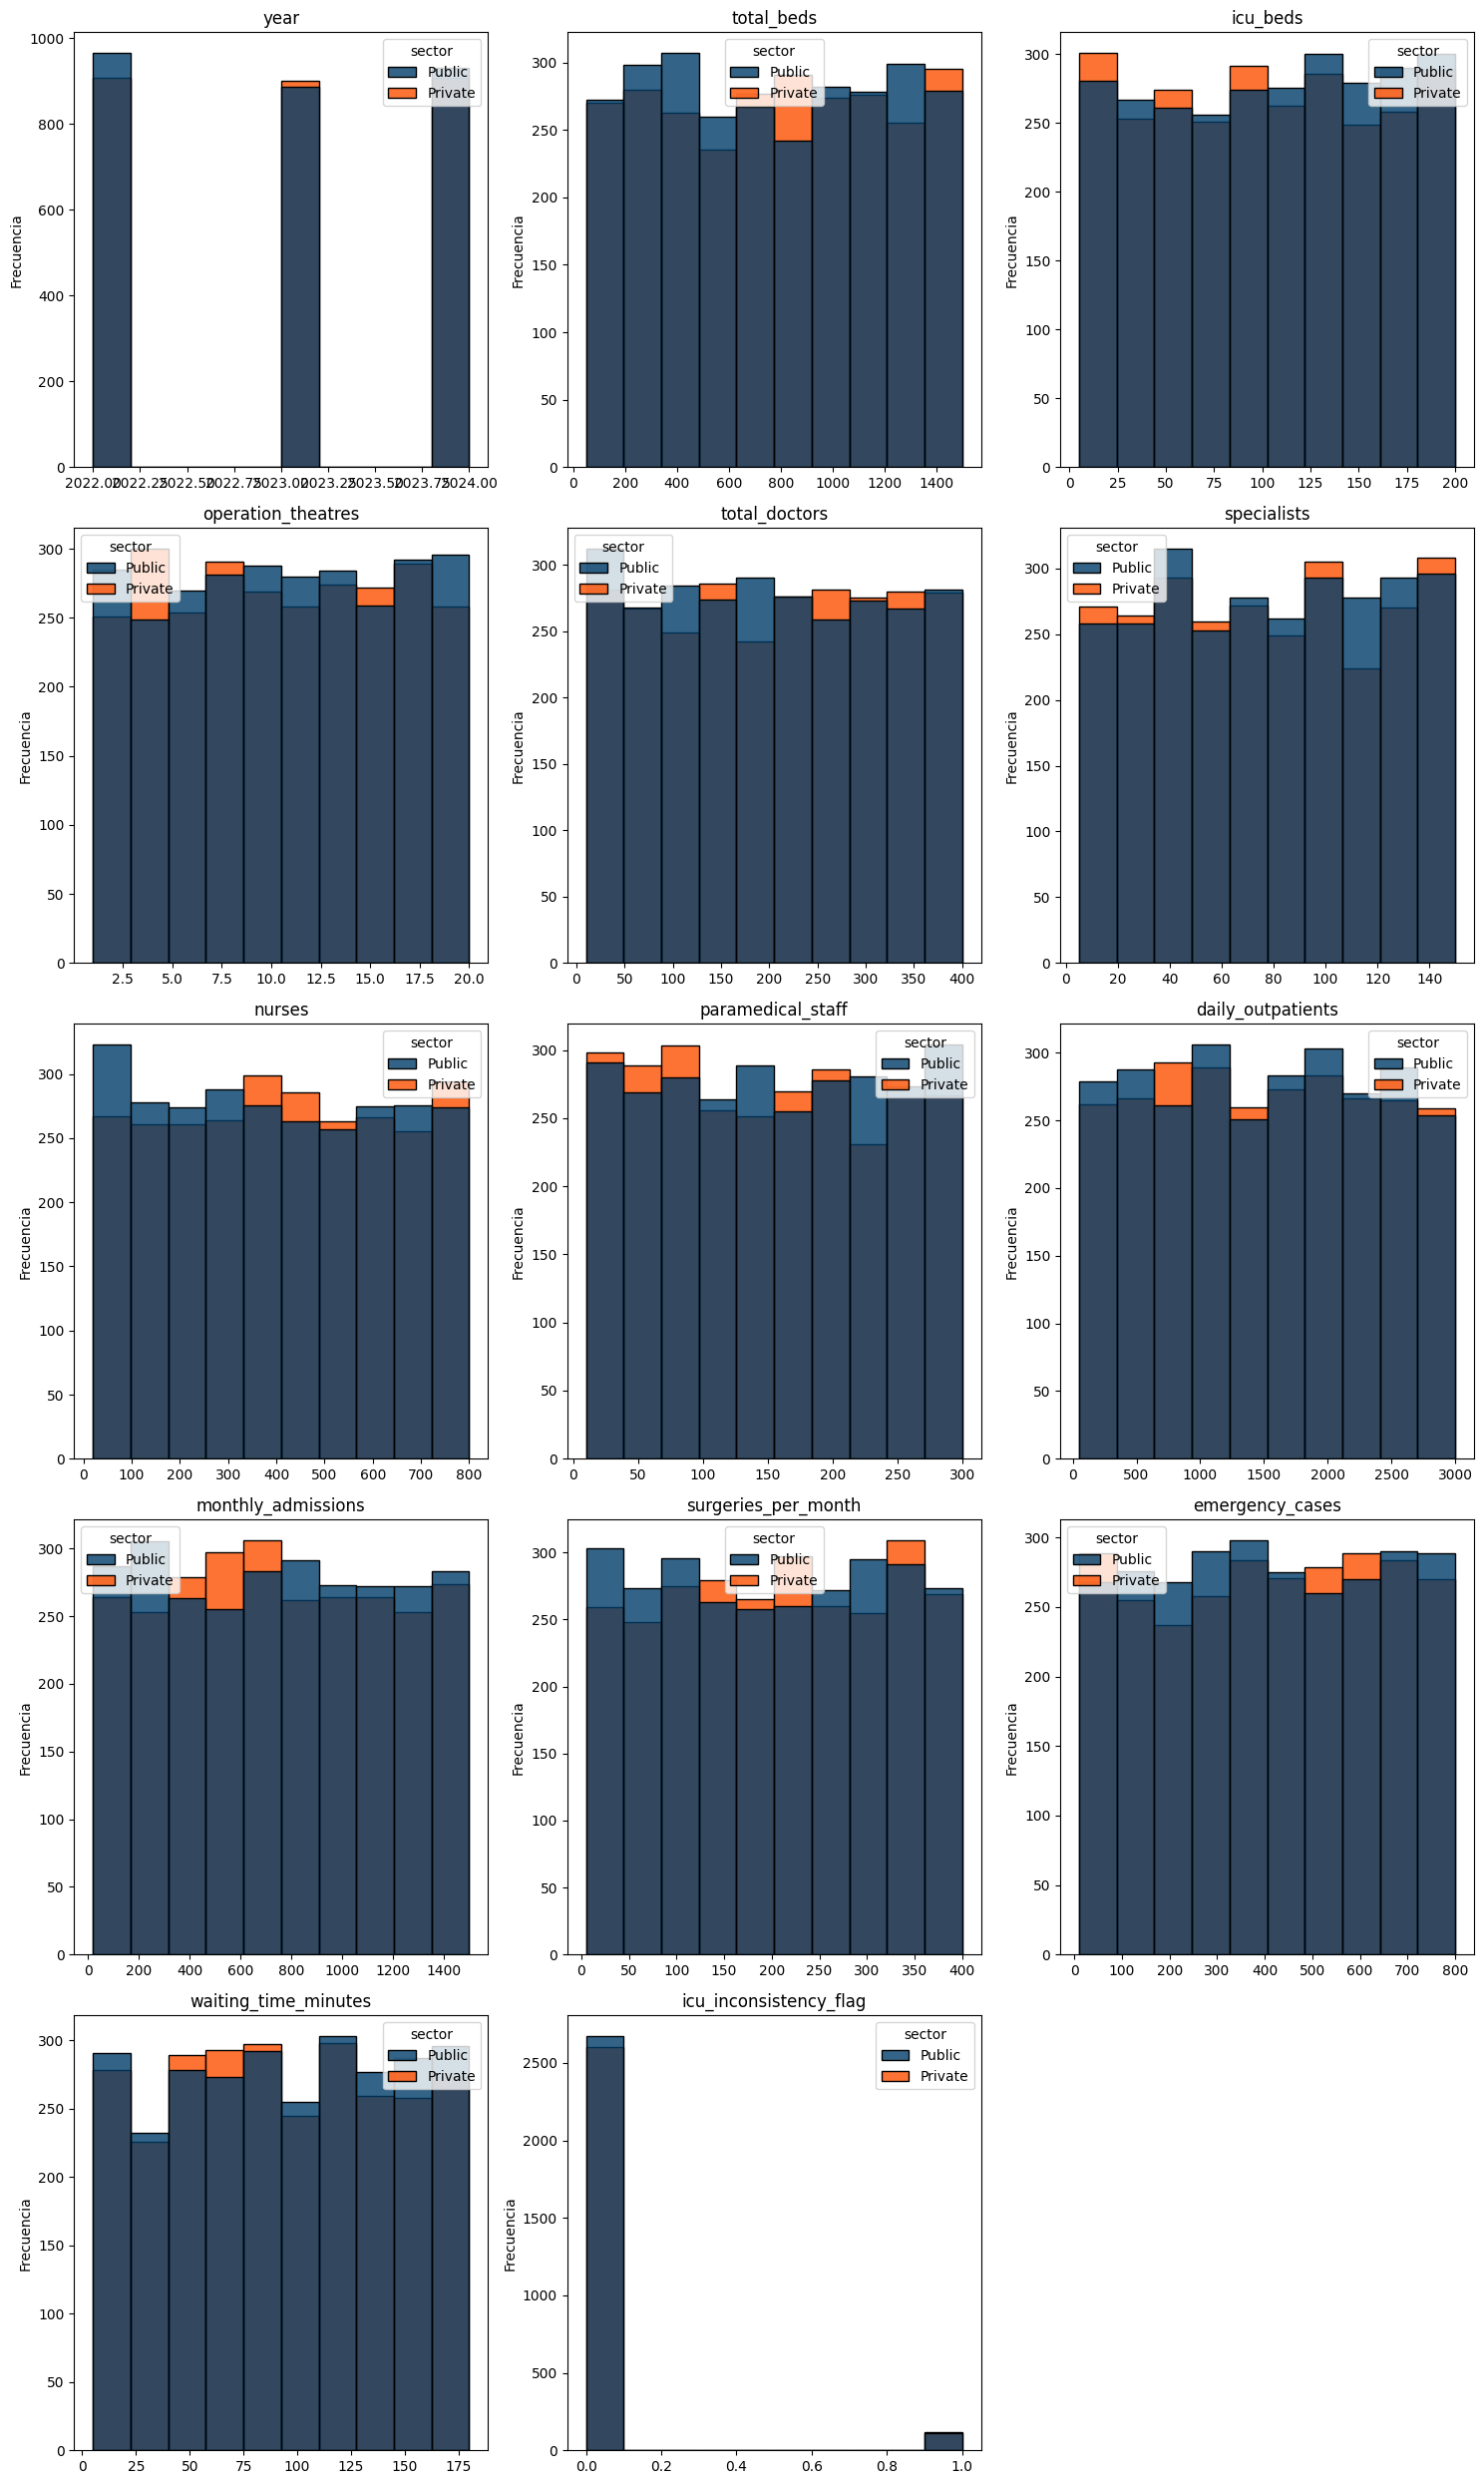

In [5]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue="sector",
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        alpha=0.8,
        ax=ax,
        bins=10
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

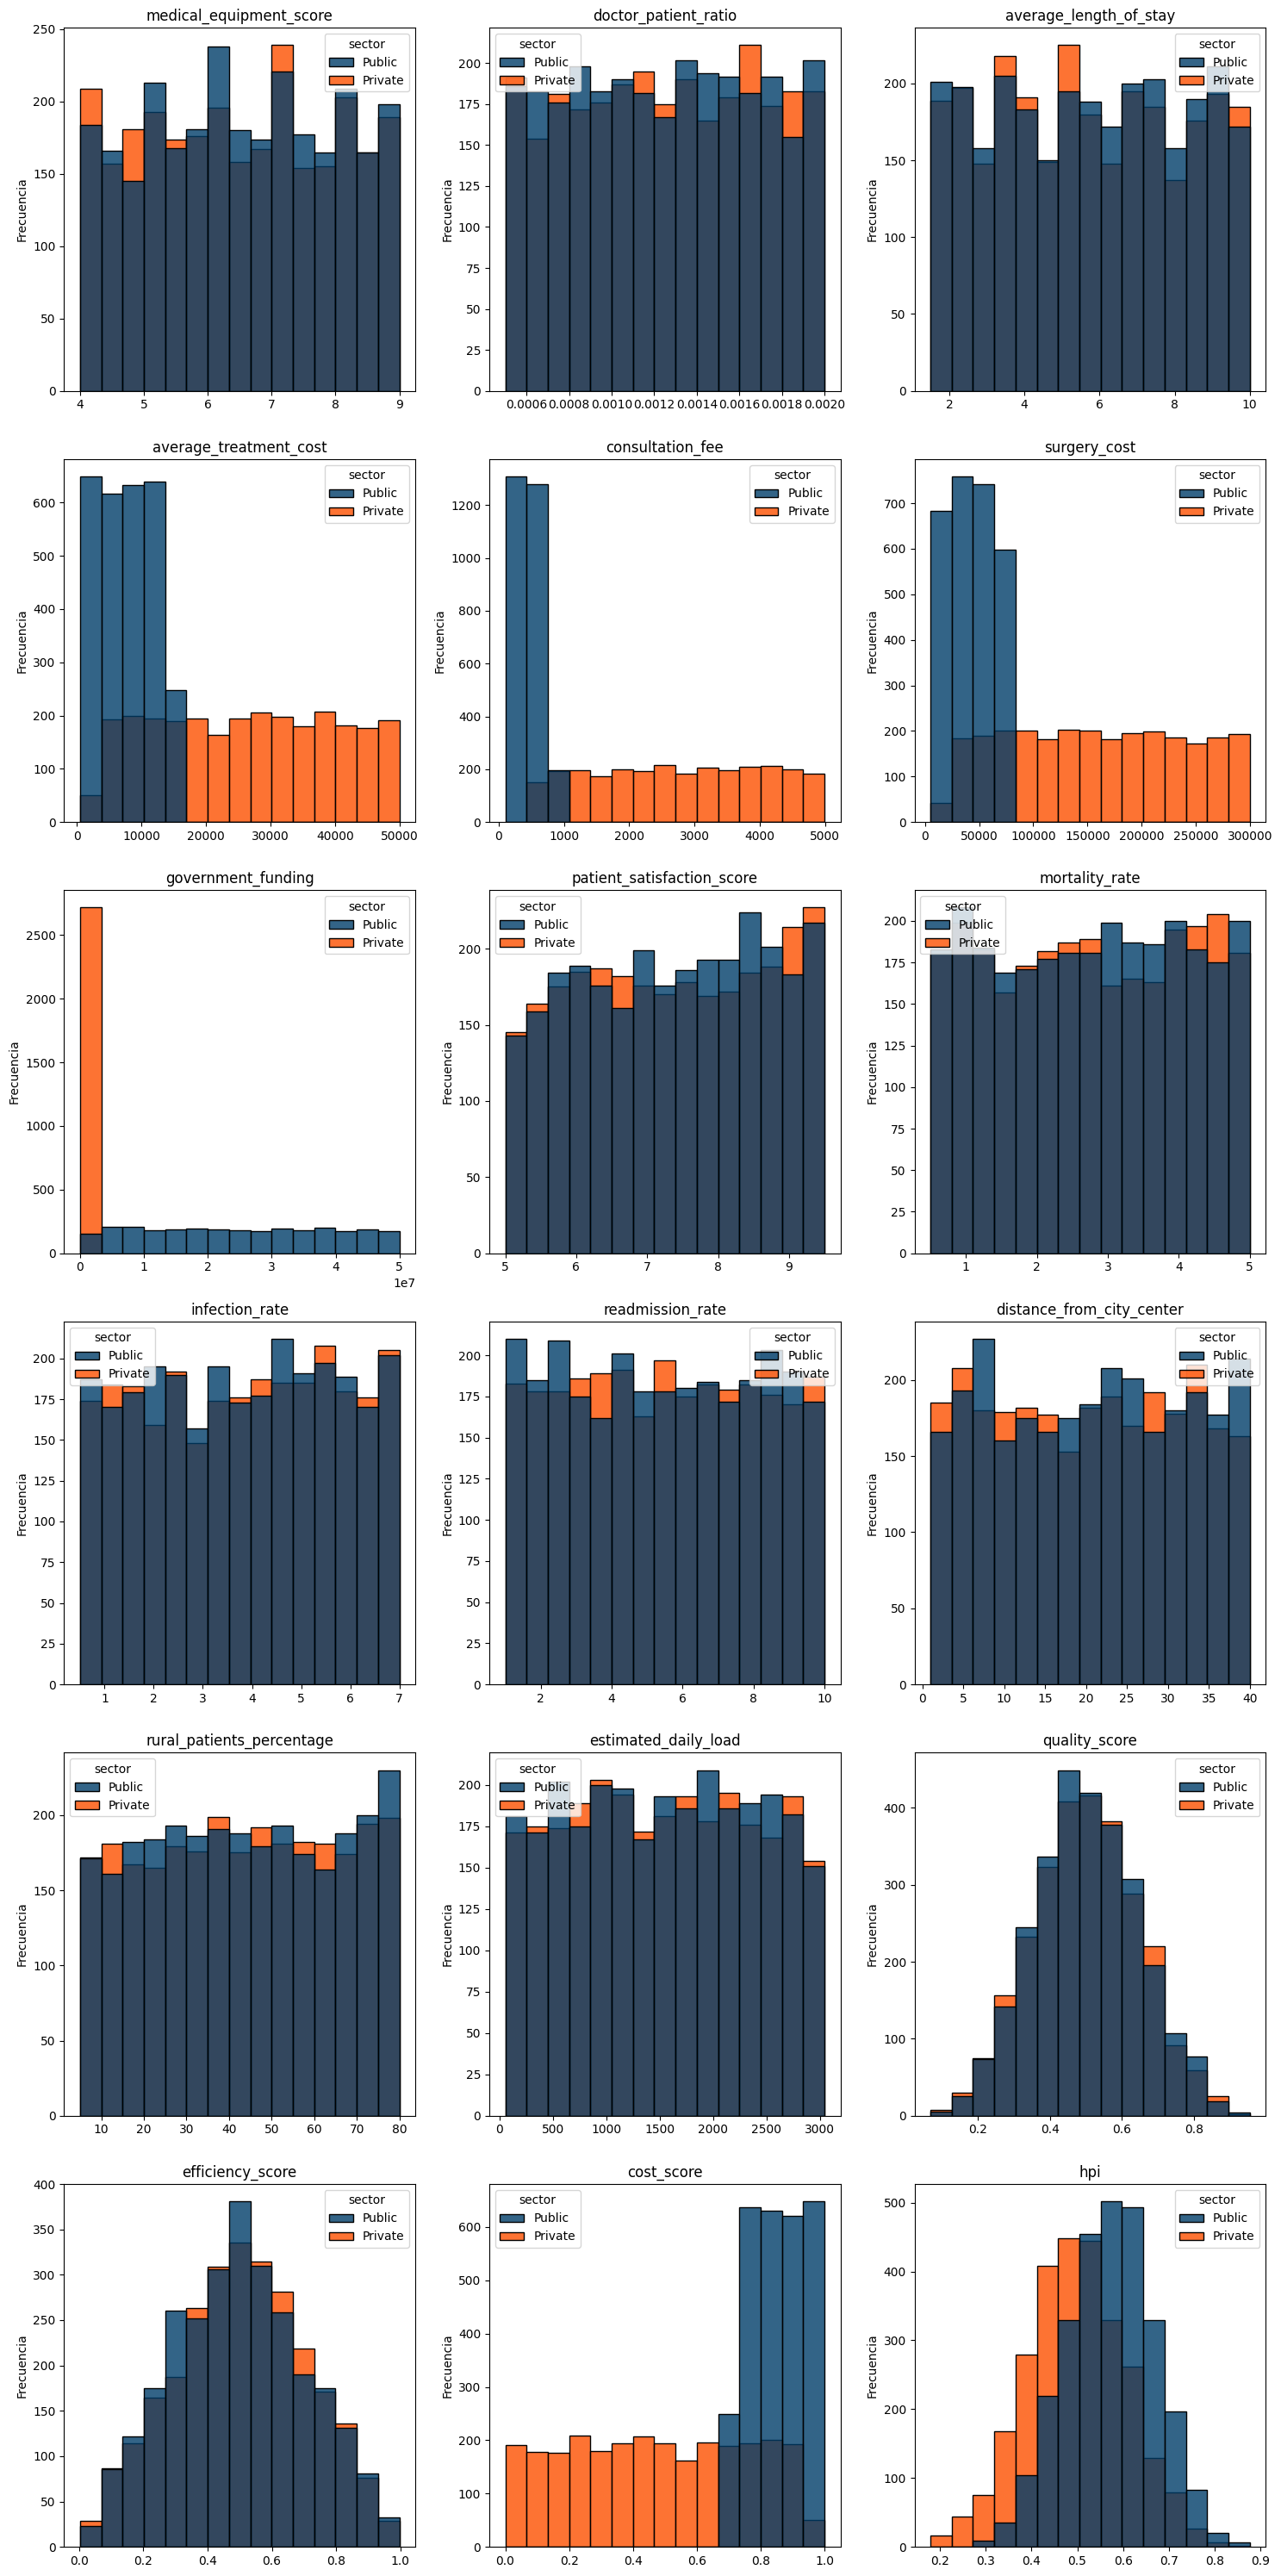

In [6]:
# seleccionar variables enteras
float_cols = df.select_dtypes(include=["float64", "float32"]).columns

n_cols = 3
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue="sector",
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        alpha=0.8,
        ax=ax,
        bins=15,
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [7]:
import scipy.stats as stats

# Hipótesis: Los hospitales públicos tienen mejor HPI que los públicos
public_hpi = df[df['sector'] == 'Public']['hpi']
private_hpi = df[df['sector'] == 'Private']['hpi']

t_stat, p_value = stats.ttest_ind(public_hpi, private_hpi, equal_var=False)
print(f"T-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.")
else:
    print("No rechazamos la hipótesis nula: No hay diferencia significativa en HPI entre sectores.")

print(f"HPI promedio público: {public_hpi.mean():.3f}")
print(f"HPI promedio privado: {private_hpi.mean():.3f}")

T-test: t-statistic = 26.543, p-value = 0.000
Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.
HPI promedio público: 0.571
HPI promedio privado: 0.497


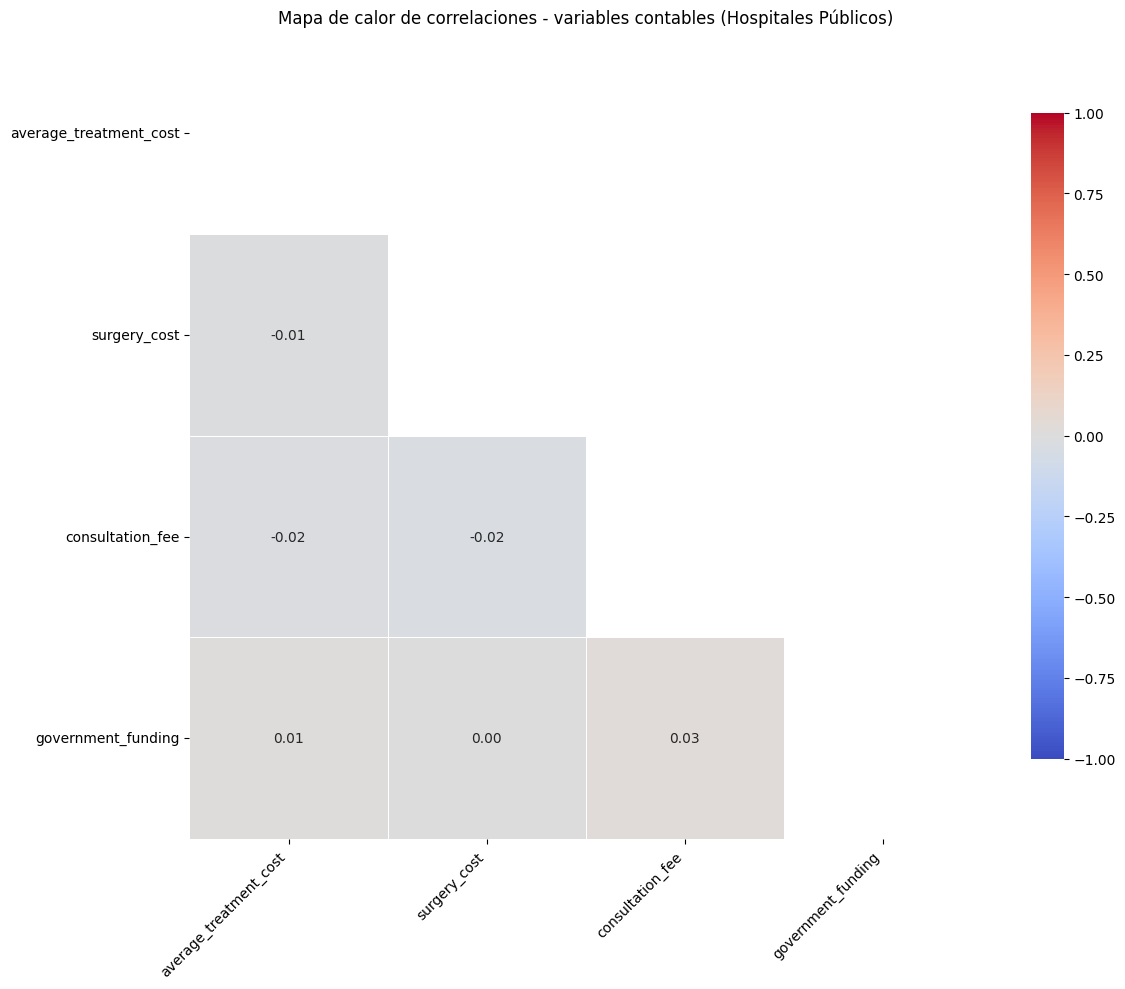

In [9]:
# Correlation heatmap - variables de contabilidad
# Hospitales públicos
publicos = df[df['sector'] == 'Public']
cost_cols = [
    'average_treatment_cost',
    'surgery_cost',
    'consultation_fee',
    'government_funding'
]

corr_matrix = publicos[cost_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    fmt=".2f",
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1
)

plt.title("Mapa de calor de correlaciones - variables contables (Hospitales Públicos)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()